In [25]:
# PART 1: LINEAR REGRESSION FROM SCRATCH

# Synthetic Data Generation
# We invent fake data with a known formula, then later try to recover that formula with a model.

import numpy as np              # numbers & arrays
import matplotlib.pyplot as plt # plotting (used in later cells)

# --- Make the dataset ---
np.random.seed(42)   # same random numbers every run (reproducible)
n_samples = 200      # how many data points (rows)
n_features = 3       # how many inputs per point: x1, x2, x3 (columns)

# Hidden "true" formula we will pretend nature used:
#   y = 3*x1 + 1.5*x2 - 2*x3 + 5 + noise
X = np.random.randn(n_samples, n_features)  # X is (200, 3): 200 points, 3 features each
                                             # randn = random numbers from a normal (bell curve) distribution

true_weights = np.array([3.0, 1.5, -2.0])  # Weights (W): how much each feature matters
#   3.0  → x1 strongly increases y
#   1.5  → x2 also increases y (less than x1)
#  -2.0  → x3 decreases y

true_bias = 5.0  # Bias (b): baseline offset added even if all x's are 0
                 # like the intercept in y = mx + b

noise = np.random.randn(n_samples) * 1.5  # small random mess so data isn't perfect
                                           # * 1.5 controls how noisy it is

y = X @ true_weights + true_bias + noise
# @ = matrix multiply: for each row, does 3*x1 + 1.5*x2 + (-2)*x3
# then add bias and noise → y is the target we want to predict (shape: 200,)

# --- What the prints mean ---
print(f"X shape: {X.shape}")
# → (200, 3) = 200 samples, 3 features

print(f"y shape: {y.shape}")
# → (200,) = one target value per sample

print(f"True weights: {true_weights}, True bias: {true_bias}")
# → the secret answer a good model should learn: W≈[3, 1.5, -2], b≈5

print(f"y range: [{y.min():.2f}, {y.max():.2f}]")
# → smallest and largest y in the data (shows the scale of targets)

# --- Train / test split (80% train, 20% test) ---
# Train = data the model learns from
# Test  = held-out data to check if it generalizes (not just memorized)
split_idx = int(0.8 * n_samples)              # 0.8 * 200 = 160
X_train, X_test = X[:split_idx], X[split_idx:]  # first 160 rows / last 40 rows
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTrain: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
# → Train: 160, Test: 40


X shape: (200, 3)
y shape: (200,)
True weights: [ 3.   1.5 -2. ], True bias: 5.0
y range: [-6.64, 17.84]

Train: 160 samples, Test: 40 samples


In [4]:
# Linear Regression with Normal Equation (Closed Form)
# Instead of looping with gradient descent, we solve for the best weights in one shot.

class LinearRegressionClosedForm:
    """
    Solves: w = (X^T X)^(-1) X^T y
    That formula is the exact W that minimizes MSE for linear regression.
    Best for smaller data (not huge feature counts).
    """
    def __init__(self, fit_intercept=True):
        # fit_intercept=True means: also learn a bias (the +b in y = Xw + b)
        self.fit_intercept = fit_intercept
        self.weights = None  # will hold W after fit()
        self.bias = None     # will hold b after fit()
    
    def fit(self, X, y):
        # Learn weights from training data (X_train, y_train)
        
        # Add a column of 1s so bias is learned as just another weight.
        # Example: one row [x1, x2, x3] becomes [1, x1, x2, x3]
        # The weight on that "1" column IS the bias.
        if self.fit_intercept:
            X_aug = np.column_stack([np.ones(X.shape[0]), X])  # shape: (n, 4) if X has 3 features
        else:
            X_aug = X  # no bias column
        
        # Normal equation pieces:
        # XtX = X^T X   → how features relate to each other
        # Xty = X^T y   → how features relate to the target
        # solve XtX @ w = Xty  → same as w = (X^T X)^(-1) X^T y, but more numerically stable
        XtX = X_aug.T @ X_aug
        Xty = X_aug.T @ y
        w = np.linalg.solve(XtX, Xty)  # all weights including bias (if added)
        
        # Split the big weight vector back into bias + feature weights
        if self.fit_intercept:
            self.bias = w[0]       # first number = bias (from the column of 1s)
            self.weights = w[1:]   # rest = weight for each feature
        else:
            self.bias = 0.0
            self.weights = w
        
        return self  # return model so you can write model.fit(...).predict(...)
    
    def predict(self, X):
        # Use learned W and b: y_hat = X @ W + b
        return X @ self.weights + self.bias


# --- Train on train set, check on test set ---
model_cf = LinearRegressionClosedForm(fit_intercept=True)  # create model (with bias)
model_cf.fit(X_train, y_train)                             # learn W and b from training data
y_pred_cf = model_cf.predict(X_test)                       # predict targets for unseen test X

print(f"Learned weights: {model_cf.weights}")
# → should be close to true_weights [3.0, 1.5, -2.0]

print(f"Learned bias: {model_cf.bias:.4f}")
# → should be close to true_bias 5.0

print(f"True weights: {true_weights}, True bias: {true_bias}")
# → the secret values we used to generate the data (for comparison)

print(f"\nWeight error: {np.linalg.norm(model_cf.weights - true_weights):.4f}")
# → how far learned W is from true W (smaller = better; 0 would be perfect)
#   not exactly 0 because of the noise we added to y

Learned weights: [ 2.91817489  1.64465479 -1.84416594]
Learned bias: 4.9537
True weights: [ 3.   1.5 -2. ], True bias: 5.0

Weight error: 0.2278


Epoch 0: loss = 42.1134
Epoch 20: loss = 20.8585
Epoch 40: loss = 10.9783
Epoch 60: loss = 6.3835
Epoch 80: loss = 4.2457
Epoch 100: loss = 3.2507
Epoch 120: loss = 2.7873
Epoch 140: loss = 2.5714
Epoch 160: loss = 2.4708
Epoch 180: loss = 2.4238

Closed-form predictions (first 5): [ 5.97138681  6.92633173 -1.82330173  4.78405746  0.9540188 ]
Gradient descent predictions (first 5): [ 5.88588194  6.80812154 -1.76869453  4.65093292  0.93255555]
Max difference: 0.326986


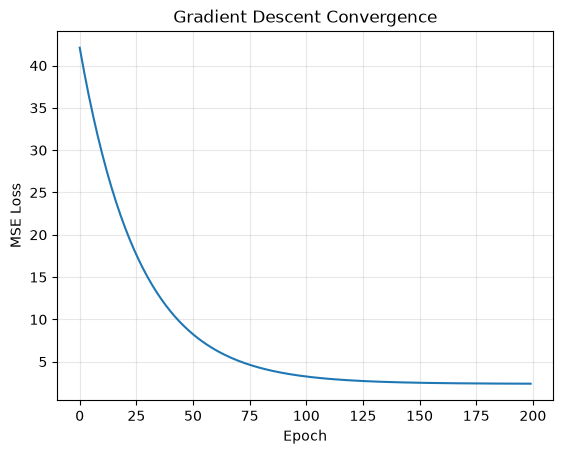

In [6]:
# Linear Regression with Gradient Descent
# Same goal as closed-form (learn W and b), but we improve them step-by-step instead of one formula.

class LinearRegressionGD:
    """
    Minimizes MSE by walking downhill on the loss surface (gradient descent).
    Use this when there are many features (closed-form gets slow / unstable).
    """
    def __init__(self, lr=0.01, n_epochs=100, fit_intercept=True):
        self.lr = lr                # learning rate: how big each update step is
        self.n_epochs = n_epochs    # how many full passes over the training data
        self.fit_intercept = fit_intercept  # kept for API consistency (bias always used here)
        self.weights = None         # W for each feature
        self.bias = None            # b (intercept)
        self.loss_history = []      # store loss each epoch (for the plot)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape  # e.g. 160 samples, 3 features
        
        # Start with small random weights (not zeros — helps learning start moving)
        # * sqrt(2/n_features) keeps initial values from being too huge
        self.weights = np.random.randn(n_features) * np.sqrt(2.0 / n_features)
        self.bias = 0.0
        
        for epoch in range(self.n_epochs):
            # --- Forward: make predictions with current W, b ---
            y_pred = X @ self.weights + self.bias  # y_hat = XW + b
            
            # --- Loss: how wrong are we? (Mean Squared Error) ---
            error = y_pred - y           # positive = overshot, negative = undershot
            loss = np.mean(error ** 2)   # average of squared errors
            self.loss_history.append(loss)
            
            # --- Gradients: which way should W and b move to reduce loss? ---
            # dL/dW = (2/n) * X^T @ error
            # dL/db = (2/n) * sum(error)
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)
            
            # --- Update: take a small step opposite the gradient ---
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # Print every 20 epochs so we can watch loss fall
            if epoch % 20 == 0:
                print(f"Epoch {epoch}: loss = {loss:.4f}")
        
        return self
    
    def predict(self, X):
        # Same prediction formula as closed-form: y_hat = XW + b
        return X @ self.weights + self.bias


# --- Train GD model, then compare to closed-form model ---
model_gd = LinearRegressionGD(lr=0.01, n_epochs=200)  # 200 steps, step size 0.01
model_gd.fit(X_train, y_train)                        # learn W, b by gradient descent
y_pred_gd = model_gd.predict(X_test)                  # predict on held-out test set

print(f"\nClosed-form predictions (first 5): {y_pred_cf[:5]}")
# → predictions from the one-shot normal-equation model (previous cell)

print(f"Gradient descent predictions (first 5): {y_pred_gd[:5]}")
# → predictions from this GD model — should look almost the same

print(f"Max difference: {np.max(np.abs(y_pred_cf - y_pred_gd)):.6f}")
# → biggest gap between the two models' predictions
#   small number ⇒ GD found nearly the same solution as closed-form

# --- Plot: loss should go down as epochs increase ---
plt.plot(model_gd.loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.3)
plt.show()
# Falling curve = the model is learning (errors getting smaller)

# Key point: Both methods give nearly identical results. The closed form is exact; gradient descent approximates it. 
# When n_features is large (like in deep learning), we can only use gradient descent

In [5]:
# Adding L2 Regularization (Ridge Regression)
# Same as linear regression + GD, but we also punish large weights so the model stays simpler.

class RidgeRegression:
    """
    Linear regression with an L2 penalty.
    Loss = MSE + alpha * (sum of weight^2)
    
    That extra term pulls weights toward 0 → less overfitting
    (model less likely to memorize noise in the training data).
    """
    def __init__(self, alpha=1.0, lr=0.01, n_epochs=200):
        self.alpha = alpha      # how strong the "don't use huge weights" penalty is
                                # alpha=0 → plain linear regression (no penalty)
                                # bigger alpha → smaller weights
        self.lr = lr            # how big each weight nudge (update) is
        self.n_epochs = n_epochs  # how many times we go through the training data
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape  # e.g. 160 rows, 3 input columns
        self.weights = np.random.randn(n_features) * 0.01  # start with tiny random weights
        self.bias = 0.0
        
        for epoch in range(self.n_epochs):
            # Predict with current weights
            y_pred = X @ self.weights + self.bias
            error = y_pred - y  # how far off each prediction is
            
            # --- Total loss = fit error + size penalty ---
            mse = np.mean(error ** 2)                      # usual "how wrong" term
            l2_penalty = self.alpha * np.sum(self.weights ** 2)  # punish large |weights|
            loss = mse + l2_penalty
            self.loss_history.append(loss)
            
            # --- Gradients (direction to nudge weights) ---
            # First part: same as normal linear regression (from MSE)
            # Second part: + 2*alpha*w  comes from the L2 penalty
            #   (derivative of alpha * w^2 is 2*alpha*w)
            # Bias has NO L2 penalty here — we only shrink feature weights
            dw = (2 / n_samples) * (X.T @ error) + 2 * self.alpha * self.weights
            db = (2 / n_samples) * np.sum(error)
            
            # Nudge weights a little opposite the gradient
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        
        return self
    
    def predict(self, X):
        return X @ self.weights + self.bias  # y_hat = XW + b


# --- Try different alpha strengths and compare ---
alphas = [0.0, 0.1, 1.0, 10.0]
for alpha in alphas:
    model = RidgeRegression(alpha=alpha, lr=0.01, n_epochs=100)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_loss = np.mean((y_pred - y_test) ** 2)  # error on unseen test data
    
    print(
        f"Alpha {alpha:4.1f}: "
        f"weights norm = {np.linalg.norm(model.weights):.3f}, "  # overall size of W (smaller = more shrunk)
        f"test MSE = {test_loss:.4f}"                            # lower = better predictions on test set
    )
# Expectation: as alpha grows, weight norm usually shrinks.
# Test MSE may get better at a sweet spot, then worse if alpha is too large
# (model becomes too shy / underfits).


Alpha  0.0: weights norm = 3.244, test MSE = 3.3280
Alpha  0.1: weights norm = 3.033, test MSE = 3.6297
Alpha  1.0: weights norm = 1.842, test MSE = 6.7724
Alpha 10.0: weights norm = 0.345, test MSE = 14.2032


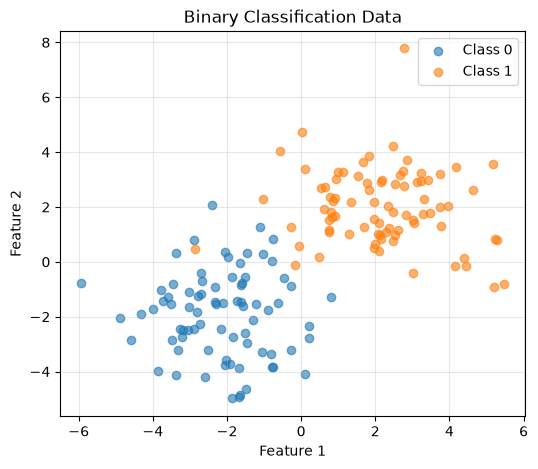

In [7]:
# PART 2: LOGISTIC REGRESSION 

# Binary Classification Data

# Generate two clusters of points
np.random.seed(42)
n_per_class = 100

# Class 0: centered at (-2, -2)
X0 = np.random.randn(n_per_class, 2) * 1.5 + np.array([-2, -2])
y0 = np.zeros(n_per_class)

# Class 1: centered at (2, 2)
X1 = np.random.randn(n_per_class, 2) * 1.5 + np.array([2, 2])
y1 = np.ones(n_per_class)

X_cls = np.vstack([X0, X1])
y_cls = np.hstack([y0, y1])

# Shuffle
idx = np.random.permutation(len(y_cls))
X_cls, y_cls = X_cls[idx], y_cls[idx]

# Train-test split
split = int(0.8 * len(y_cls))
Xc_train, Xc_test = X_cls[:split], X_cls[split:]
yc_train, yc_test = y_cls[:split], y_cls[split:]

# Visualize
plt.figure(figsize=(6, 5))
plt.scatter(Xc_train[yc_train==0, 0], Xc_train[yc_train==0, 1], alpha=0.6, label='Class 0')
plt.scatter(Xc_train[yc_train==1, 0], Xc_train[yc_train==1, 1], alpha=0.6, label='Class 1')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.legend(); plt.title('Binary Classification Data')
plt.grid(True, alpha=0.3)
plt.show()

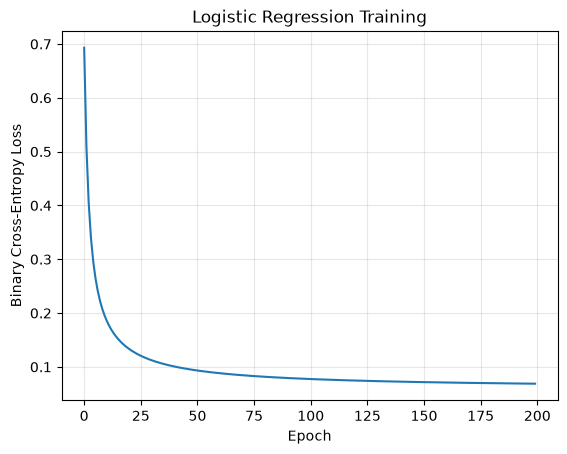

Test Accuracy: 0.975


In [11]:
# Logistic Regression from Scratch
# Linear regression predicted a number (y).
# Logistic regression predicts a CLASS: 0 or 1 (e.g. spam / not spam).

class LogisticRegression:
    """
    Binary classification with gradient descent.
    
    Step 1: compute a score (logit) = X @ w + b   (same idea as linear regression)
    Step 2: squash it with sigmoid into a probability between 0 and 1
            P(y=1 | x) = sigmoid(score)
    
    Loss = Binary Cross-Entropy (how wrong the probabilities are)
    """
    def __init__(self, lr=0.1, n_epochs=200):
        self.lr = lr              # how big each weight nudge is
        self.n_epochs = n_epochs  # how many times we go through the training data
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def _sigmoid(self, z):
        """Turn any number into a probability in (0, 1)."""
        # Example: sigmoid(0)=0.5, big positive → ~1, big negative → ~0
        # Clip z so exp() doesn't explode on huge numbers
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        # y should be 0s and 1s (class labels), not continuous numbers
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)  # start at 0
        self.bias = 0.0
        
        for epoch in range(self.n_epochs):
            # --- Forward ---
            logits = X @ self.weights + self.bias  # raw scores (can be any number)
            probs = self._sigmoid(logits)          # probabilities that class = 1
            
            # --- Binary cross-entropy loss ---
            # If true label y=1: we want log(prob) high  → punish low prob
            # If true label y=0: we want log(1-prob) high → punish high prob
            # Formula: -mean( y*log(p) + (1-y)*log(1-p) )
            eps = 1e-15  # tiny number so we never take log(0)
            loss = -np.mean(
                y * np.log(probs + eps) + (1 - y) * np.log(1 - probs + eps)
            )
            self.loss_history.append(loss)
            
            # --- Gradients ---
            # (probs - y) is: "how much we overshot the true 0/1 label"
            dw = (1 / n_samples) * X.T @ (probs - y)
            db = (1 / n_samples) * np.sum(probs - y)
            
            # Nudge weights to reduce loss
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        
        return self
    
    def predict_proba(self, X):
        # Return probability of class 1 for each row (a number between 0 and 1)
        logits = X @ self.weights + self.bias
        return self._sigmoid(logits)
    
    def predict(self, X, threshold=0.5):
        # Turn probabilities into hard labels:
        #   prob >= 0.5 → class 1
        #   prob <  0.5 → class 0
        return (self.predict_proba(X) >= threshold).astype(int)


# --- Train on the classification data from the previous cell ---
model_lr = LogisticRegression(lr=0.1, n_epochs=200)
model_lr.fit(Xc_train, yc_train)

# Loss should fall as the model learns better probabilities
plt.plot(model_lr.loss_history)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Logistic Regression Training')
plt.grid(True, alpha=0.3)
plt.show()

# Accuracy = fraction of test points we labeled correctly
y_pred_lr = model_lr.predict(Xc_test)
accuracy = np.mean(y_pred_lr == yc_test)  # True/False → 1/0, then average
print(f"Test Accuracy: {accuracy:.3f}")
# e.g. 0.950 means 95% of test samples got the right class

# Key insight: Logistic regression finds a linear decision boundary. 
# If the classes aren't linearly separable, it will fail. This is why we need neural networks for complex patterns

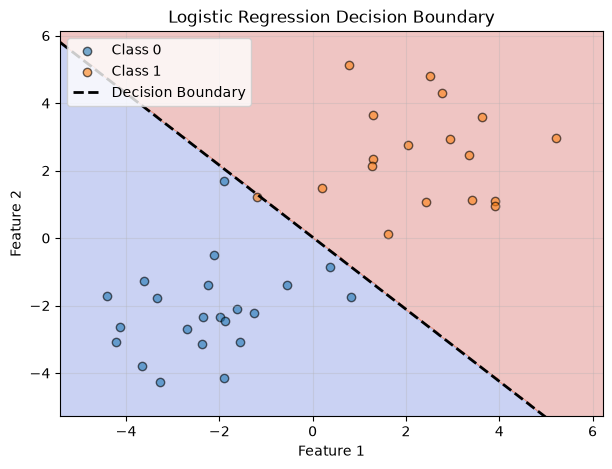

In [12]:
# Visualize the Decision Boundary
# This chart shows HOW the model splits the 2D plane into Class 0 vs Class 1.
#
# What you should see in the plot:
#   - Colored background regions = model's predicted class everywhere in the plane
#       (one color for "I predict 0", another for "I predict 1")
#   - Scattered points = real test examples (true labels)
#   - Dashed black line = decision boundary
#       (where the model is unsure: probability ≈ 0.5, score = 0)
#
# If points mostly sit in the matching color region → model is separating well.
# Points on the wrong side of the line → mistakes.

def plot_decision_boundary(model, X, y, title):
    # 1) Figure out the plot window (a bit bigger than the data range)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1  # feature 1 axis limits
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1  # feature 2 axis limits
    
    # 2) Build a dense grid of (x1, x2) points covering the whole window
    #    like asking the model: "what class is every pixel on this map?"
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200),
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]          # shape: (200*200, 2) all grid points
    Z = model.predict(grid).reshape(xx.shape)    # predicted class 0/1 at each grid point
    
    plt.figure(figsize=(7, 5))
    
    # 3) Paint the background by predicted class (the two regions)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    # 4) Draw the actual data points on top
    plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.6, label='Class 0', edgecolors='k')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.6, label='Class 1', edgecolors='k')
    
    # 5) Draw the straight decision line: where w1*x1 + w2*x2 + b = 0
    #    Rearranged: x2 = -(w1*x1 + b) / w2
    #    On this line, sigmoid(score) = 0.5 → coin-flip between classes
    if hasattr(model, 'weights'):
        w1, w2 = model.weights
        b = model.bias
        x_boundary = np.array([x_min, x_max])
        y_boundary = -(w1 * x_boundary + b) / w2
        plt.plot(x_boundary, y_boundary, 'k--', linewidth=2, label='Decision Boundary')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title(title)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=0.3)
    plt.show()


# Use the trained logistic model on the test points
plot_decision_boundary(model_lr, Xc_test, yc_test, 'Logistic Regression Decision Boundary')


In [14]:
# PART 3: EVALUATION METRICS
# Accuracy alone can lie. These metrics tell DIFFERENT stories about model quality.
#
# Setup: binary classification — true labels are 0 or 1, predictions are 0 or 1.
# Think of Class 1 as the "positive" thing we care about detecting
# (e.g. disease present, spam email, fraud). Class 0 = negative / normal.
#
# Every prediction falls into exactly one of 4 buckets:
#
#                    Predicted 0          Predicted 1
#   Actually 0         TN (correct)         FP (false alarm)
#   Actually 1         FN (missed it)       TP (caught it)
#
#   TP = True Positive  → said 1, and it really was 1  (hit)
#   FP = False Positive → said 1, but it was really 0  (false alarm)
#   TN = True Negative  → said 0, and it really was 0  (correct reject)
#   FN = False Negative → said 0, but it was really 1  (miss)
#
# Confusion matrix is just those 4 counts arranged in a table.

# All Metrics from Scratch

def compute_metrics(y_true, y_pred):
    """
    Compute classification metrics from scratch (no sklearn).
    y_true = real labels, y_pred = model's hard 0/1 predictions.
    """
    # --- Confusion matrix counts ---
    tp = np.sum((y_true == 1) & (y_pred == 1))  # correctly predicted positive
    fp = np.sum((y_true == 0) & (y_pred == 1))  # negative, wrongly called positive
    tn = np.sum((y_true == 0) & (y_pred == 0))  # correctly predicted negative
    fn = np.sum((y_true == 1) & (y_pred == 0))  # positive, wrongly called negative
    
    # --- Accuracy: overall "how often am I right?" ---
    #   (TP + TN) / total
    # Good when classes are balanced.
    # Bad example: 99% healthy patients. Predict "healthy" always → 99% accuracy,
    # but you never catch sick people (useless model).
    accuracy = (tp + tn) / len(y_true)
    
    # --- Precision: of the times I predicted 1, how often was I right? ---
    #   TP / (TP + FP)
    # High precision = few false alarms.
    # Care about this when false alarms are costly
    # (e.g. wrongly flagging innocent people as fraud).
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    # --- Recall (Sensitivity): of all real 1s, how many did I catch? ---
    #   TP / (TP + FN)
    # High recall = few misses.
    # Care about this when missing positives is dangerous
    # (e.g. cancer screening — missing a sick patient is bad).
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    # --- Specificity: of all real 0s, how many did I correctly call 0? ---
    #   TN / (TN + FP)
    # High specificity = good at recognizing negatives (few false alarms on 0s).
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    # --- F1 Score: balance of precision and recall ---
    #   2 * precision * recall / (precision + recall)
    # Harmonic mean — if either precision or recall is low, F1 is low.
    # Useful single number when you care about both false alarms AND misses.
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    
    # --- Print everything ---
    print(f"Confusion Matrix:")
    print(f"  TP={tp:3d}  FP={fp:3d}")
    print(f"  FN={fn:3d}  TN={tn:3d}")
    print(f"\nAccuracy:    {accuracy:.4f}  ← overall correct rate")
    print(f"Precision:   {precision:.4f}  ← when we say 1, how often correct?")
    print(f"Recall:      {recall:.4f}  ← of real 1s, how many did we find?")
    print(f"Specificity: {specificity:.4f}  ← of real 0s, how many correctly called 0?")
    print(f"F1 Score:    {f1:.4f}  ← balance of precision & recall")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
    }


print("Logistic Regression Performance:")
metrics_lr = compute_metrics(yc_test, y_pred_lr)
# Uses test-set true labels (yc_test) vs model predictions (y_pred_lr).
# Higher is better for all of these (max = 1.0).
#
# Quick intuition cheat sheet:
#   Want few false alarms?  → watch Precision (and Specificity)
#   Want few misses?        → watch Recall
#   Want a balanced summary? → watch F1
#   Classes very imbalanced? → distrust Accuracy alone

Logistic Regression Performance:
Confusion Matrix:
  TP= 17  FP=  0
  FN=  1  TN= 22

Accuracy:    0.9750  ← overall correct rate
Precision:   1.0000  ← when we say 1, how often correct?
Recall:      0.9444  ← of real 1s, how many did we find?
Specificity: 1.0000  ← of real 0s, how many correctly called 0?
F1 Score:    0.9714  ← balance of precision & recall


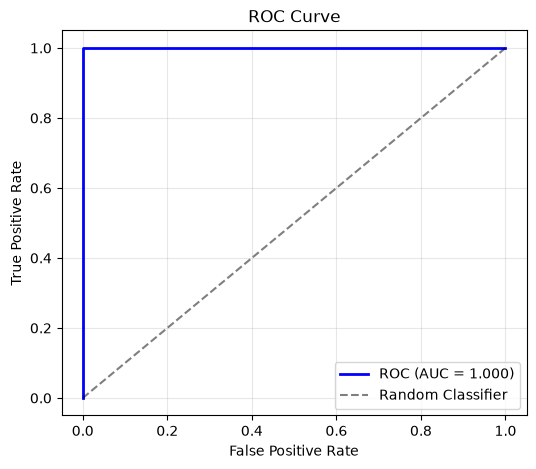

In [18]:
# ROC Curve from Scratch
#
# WHAT IS ROC?
#   ROC = Receiver Operating Characteristic
#   (old name from radar/signal detection; in ML it just means this plot)
#
#   It is a graph that shows how well a binary classifier separates two classes
#   when you try MANY decision thresholds — not just the usual 0.5.
#
#   X-axis: FPR (False Positive Rate) = false alarm rate
#           "Of all real negatives (0s), how often did we wrongly say 1?"
#   Y-axis: TPR (True Positive Rate)  = recall / sensitivity
#           "Of all real positives (1s), how often did we correctly say 1?"
#
# WHY DO WE NEED IT?
#   Logistic regression outputs a probability (0 to 1).
#   We turn it into a class with a threshold:
#     prob >= threshold → predict class 1
#     prob <  threshold → predict class 0
#
#   Low threshold  → call "1" often  → catch more real 1s (high TPR), more false alarms (high FPR)
#   High threshold → call "1" rarely → fewer false alarms (low FPR), miss more real 1s (low TPR)
#
#   The ROC curve draws that whole tradeoff.
#
# AUC (Area Under the ROC Curve):
#   One number summarizing the curve.
#   1.0 = perfect separation
#   0.5 = random guessing (the dashed diagonal on the plot)
#   closer to 1 = better model
#
# WHAT THE CHART SHOWS:
#   Blue curve   = our model (better if it bows toward the top-left)
#   Black dashed = random classifier (AUC = 0.5)
#   Legend AUC   = area under the blue curve

def compute_roc_curve(y_true, y_scores):
    """
    Build ROC points by sweeping the threshold.
    y_true   = real labels (0 or 1)
    y_scores = predicted probabilities for class 1
    """
    # Try each unique probability as a threshold (high → low)
    thresholds = np.sort(np.unique(y_scores))[::-1]
    tpr_list = []  # True Positive Rate (Recall)
    fpr_list = []  # False Positive Rate (false alarm rate)
    
    for threshold in thresholds:
        # Hard 0/1 predictions at this cutoff
        y_pred = (y_scores >= threshold).astype(int)
        
        tp = np.sum((y_true == 1) & (y_pred == 1))  # correctly predicted 1
        fp = np.sum((y_true == 0) & (y_pred == 1))  # false alarm
        fn = np.sum((y_true == 1) & (y_pred == 0))  # missed a real 1
        tn = np.sum((y_true == 0) & (y_pred == 0))  # correctly predicted 0
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # of real 1s, fraction we found
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # of real 0s, fraction we wrongly called 1
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    
    # Curve should start at (0,0) and end at (1,1)
    tpr_list = [0.0] + tpr_list + [1.0]
    fpr_list = [0.0] + fpr_list + [1.0]
    
    # AUC = area under the curve (trapezoid rule)
    auc = np.trapezoid(tpr_list, fpr_list)
    
    return np.array(fpr_list), np.array(tpr_list), auc


# Get probabilities for class 1 (not hard labels yet)
y_scores_lr = model_lr.predict_proba(Xc_test)
fpr, tpr, auc = compute_roc_curve(yc_test, y_scores_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate')   # false alarm rate
plt.ylabel('True Positive Rate')    # how many real positives we catch
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# Ideal shape: rises quickly toward top-left (high TPR, low FPR) → AUC near 1.

Decision Tree Accuracy: 0.950


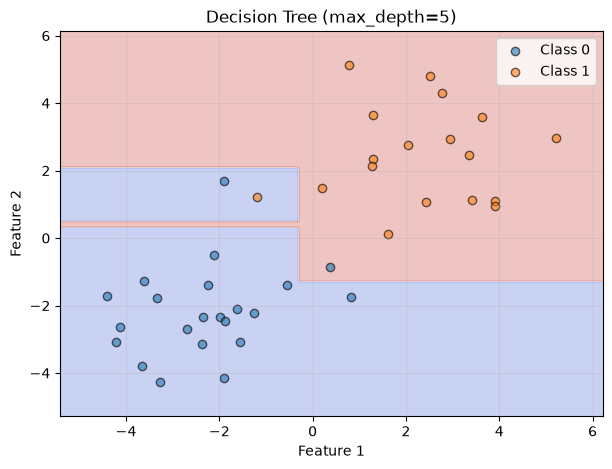

In [ ]:
# PART 4: DECISION TREE FROM SCRATCH
#
# WHAT IS A DECISION TREE?
#   A flowchart of yes/no questions about the features.
#   Example:
#     Is Feature 0 <= 1.5?
#       yes → go left  → maybe ask another question...
#       no  → go right → ...
#     Eventually you land on a leaf that says "Class 0" or "Class 1".
#
# CART = Classification And Regression Trees
#   Algorithm that builds the tree by repeatedly picking the best split.
#
# GINI IMPURITY (how "mixed" a node is):
#   0.0 = pure (all samples same class) ← good
#   0.5 = maximally mixed for 2 classes ← bad
#   Formula: 1 - sum(p_c^2)  where p_c = fraction of class c
#
# HOW TRAINING WORKS:
#   At each node, try many (feature, threshold) splits.
#   Keep the split that makes child groups as pure as possible
#   (lowest weighted Gini). Recurse until stopping rules hit.
#
# WHAT THE CHART SHOWS:
#   Decision boundary can be AXIS-ALIGNED rectangles / jagged regions
#   (not a single straight line like logistic regression).

# CART Decision Tree Implementation

class DecisionTree:
    """
    Binary decision tree using CART.
    Splits chosen by lowest Gini impurity.
    """
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth              # stop growing deeper than this
        self.min_samples_split = min_samples_split  # need at least this many samples to split
        self.tree = None                        # will store the nested dict / leaf values
    
    def _gini(self, y):
        """Gini impurity: 1 - Σ(p_c)^2  (0 = pure, higher = more mixed)"""
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)       # fraction of each class
        return 1 - np.sum(probs ** 2)
    
    def _best_split(self, X, y):
        """Try all features & thresholds; return the split with lowest weighted Gini."""
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        
        n_samples, n_features = X.shape
        
        for feature in range(n_features):                 # try each column (feature)
            thresholds = np.unique(X[:, feature])         # candidate cut values
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold    # "yes" branch
                right_mask = ~left_mask                   # "no" branch
                
                # Skip empty sides (not a real split)
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                
                y_left, y_right = y[left_mask], y[right_mask]
                gini_left = self._gini(y_left)
                gini_right = self._gini(y_right)
                
                # Weighted average: bigger child counts more
                n_left, n_right = len(y_left), len(y_right)
                gini_weighted = (n_left * gini_left + n_right * gini_right) / n_samples
                
                # Keep the cleanest split so far
                if gini_weighted < best_gini:
                    best_gini = gini_weighted
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def _build_tree(self, X, y, depth):
        """Recursively grow the tree."""
        n_samples = len(y)
        
        # STOP and make a leaf if:
        #   - too deep, OR too few samples, OR already pure (one class only)
        if (
            depth >= self.max_depth
            or n_samples < self.min_samples_split
            or len(np.unique(y)) == 1
        ):
            # Leaf prediction = majority class in this group
            return np.argmax(np.bincount(y.astype(int)))
        
        feature, threshold = self._best_split(X, y)
        
        if feature is None:  # no valid split found → leaf
            return np.argmax(np.bincount(y.astype(int)))
        
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        # Grow left and right children one level deeper
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        # Internal node stores the question + both answers
        return {
            'feature': feature,       # which column to ask about
            'threshold': threshold,   # cutoff value
            'left': left_subtree,     # if x[feature] <= threshold
            'right': right_subtree,   # otherwise
        }
    
    def fit(self, X, y):
        # Learn the tree structure from training data
        self.tree = self._build_tree(X, y, depth=0)
        return self
    
    def _predict_one(self, x, node):
        # Walk from root to a leaf for a single sample
        if isinstance(node, dict):
            # Still a question node — follow left or right
            if x[node['feature']] <= node['threshold']:
                return self._predict_one(x, node['left'])
            else:
                return self._predict_one(x, node['right'])
        else:
            # Leaf: node is just the class label (0 or 1)
            return node
    
    def predict(self, X):
        # Predict class for every row
        return np.array([self._predict_one(x, self.tree) for x in X])


# --- Train & evaluate ---
model_dt = DecisionTree(max_depth=5)
model_dt.fit(Xc_train, yc_train)
y_pred_dt = model_dt.predict(Xc_test)
dt_accuracy = np.mean(y_pred_dt == yc_test)
print(f"Decision Tree Accuracy: {dt_accuracy:.3f}")

# Boundary is piecewise / boxy (axis-aligned splits), unlike logistic's straight line
plot_decision_boundary(model_dt, Xc_test, yc_test, 'Decision Tree (max_depth=5)')

# The key difference: Unlike logistic regression, the decision tree creates non-linear, axis-aligned boundaries. 
# It can capture complex patterns but easily overfits.

# Decision tree = flowchart of yes/no feature questions ending in a class
# CART = algorithm that grows the tree by picking best splits
# Gini = how mixed a node is (0 = pure)
# Training = try splits → keep lowest weighted Gini → recurse until stop rules
# Predict = walk left/right down to a leaf
# Chart = boxy/axis-aligned regions (not a straight line like logistic regression)

In [ ]:
# Random Forest — Ensemble of Trees
#
# WHAT IS A RANDOM FOREST?
#   Many decision trees vote together. Final answer = majority class.
#
#   One tree can overfit (memorize noise). Many different trees average
#   out mistakes → usually more accurate and more stable.
#
# WHY ARE THE TREES DIFFERENT?
#   1) Bootstrap sample: each tree trains on a random sample WITH replacement
#      (some rows picked multiple times, some left out)
#   2) Random features: each tree may only see a random subset of columns
#      (controlled by max_features)
#
# This diversity is the key — if every tree were identical, voting wouldn't help.
#
# ENSEMBLE = combining several models into one stronger model.

class RandomForest:
    """
    Forest of decision trees:
      - each tree trains on a bootstrap sample of the data
      - optionally uses a random subset of features
      - prediction = majority vote across trees
    """
    def __init__(self, n_trees=10, max_depth=5, max_features=None):
        self.n_trees = n_trees            # how many trees in the forest
        self.max_depth = max_depth        # depth limit passed to each DecisionTree
        self.max_features = max_features  # if set, each tree sees only this many random columns
                                          # None → use all features
        self.trees = []                   # list of {'tree': ..., 'features': ...}
    
    def _bootstrap_sample(self, X, y):
        # Draw n_samples indices WITH replacement (some rows repeat, some missing)
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]
    
    def fit(self, X, y):
        self.trees = []
        n_features = X.shape[1]
        
        for i in range(self.n_trees):
            # 1) New random training bag for this tree
            X_sample, y_sample = self._bootstrap_sample(X, y)
            
            # 2) Optionally keep only a random subset of columns
            if self.max_features is not None:
                feature_indices = np.random.choice(
                    n_features, self.max_features, replace=False
                )
                X_sample = X_sample[:, feature_indices]
            else:
                feature_indices = np.arange(n_features)  # all columns
            
            # 3) Train one DecisionTree on this bag / feature subset
            tree = DecisionTree(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            
            # Remember which features this tree used (needed at predict time)
            self.trees.append({'tree': tree, 'features': feature_indices})
            
            if (i + 1) % 5 == 0:
                print(f"  Trained tree {i+1}/{self.n_trees}")
        
        return self
    
    def predict(self, X):
        # Each tree votes for a class; columns = trees, rows = samples
        predictions = np.zeros((X.shape[0], self.n_trees))
        
        for i, tree_info in enumerate(self.trees):
            tree = tree_info['tree']
            features = tree_info['features']
            X_subset = X[:, features]              # same columns this tree trained on
            predictions[:, i] = tree.predict(X_subset)
        
        # Majority vote per sample
        final_predictions = np.zeros(X.shape[0])
        for j in range(X.shape[0]):
            # bincount counts votes for class 0, 1, ...; argmax = winning class
            final_predictions[j] = np.argmax(np.bincount(predictions[j].astype(int)))
        
        return final_predictions


# --- Train Random Forest ---
print("Training Random Forest...")
# max_features=1 → each tree only looks at 1 random feature (extra randomness on 2D data)
model_rf = RandomForest(n_trees=20, max_depth=5, max_features=1)
model_rf.fit(Xc_train, yc_train)
y_pred_rf = model_rf.predict(Xc_test)
rf_accuracy = np.mean(y_pred_rf == yc_test)
print(f"Random Forest Accuracy: {rf_accuracy:.3f}")

# --- Compare models on the same test set ---
print("\n" + "=" * 40)
print("MODEL COMPARISON")
print("=" * 40)
print(f"Logistic Regression Accuracy: {accuracy:.3f}")
print(f"Decision Tree Accuracy:       {dt_accuracy:.3f}")
print(f"Random Forest Accuracy:       {rf_accuracy:.3f}")
# Often: Forest ≥ single Tree, because voting reduces overfitting.

# Why Random Forest works: Each tree sees different data (bootstrap) and different features. 
# Their errors are uncorrelated, so voting averages them out. This is called the wisdom of crowds.


Training Random Forest...
  Trained tree 5/20
  Trained tree 10/20
  Trained tree 15/20
  Trained tree 20/20
Random Forest Accuracy: 0.925

MODEL COMPARISON
Logistic Regression Accuracy: 0.975
Decision Tree Accuracy:       0.950
Random Forest Accuracy:       0.925


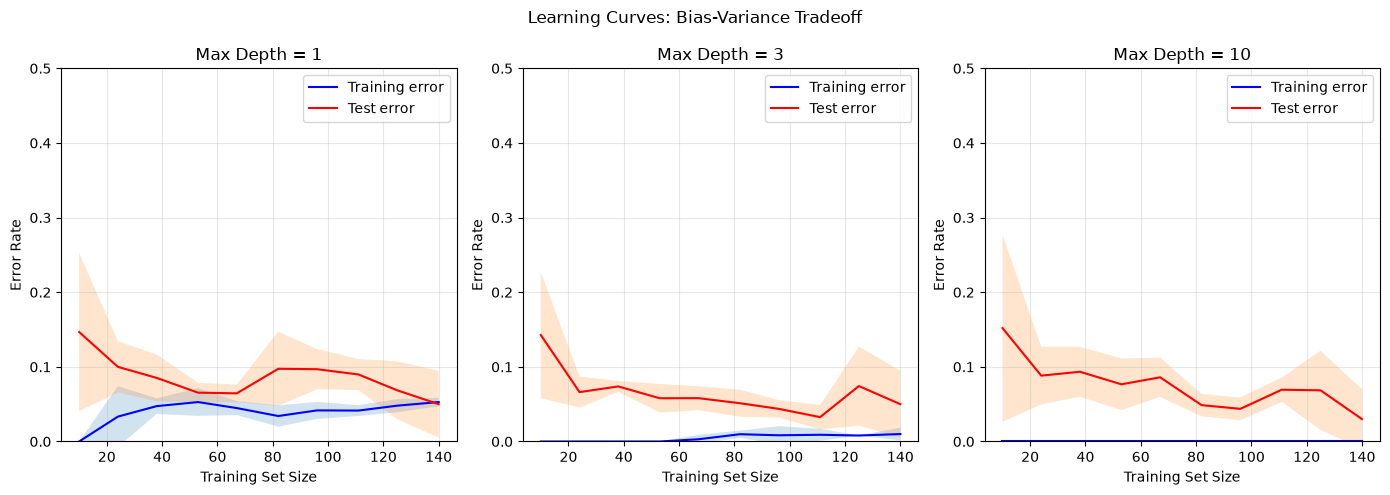

Depth=1:  High bias (underfitting) — both errors high, close together
Depth=10: High variance (overfitting) — train error low/0, test error higher
Depth=3:  Sweet spot — errors settle at a more reasonable place


In [29]:
# PART 5: BIAS-VARIANCE TRADEOFF
#
# Kid-simple idea:
#   Bias     = the model is too dumb/simple → misses the real pattern (underfitting)
#   Variance = the model is too jumpy/complex → memorizes homework, fails the quiz (overfitting)
#
# A LEARNING CURVE answers:
#   "If I give the model more training examples, do train error and test error behave well?"
#
#   Blue line = Training error (mistakes on data it studied)
#   Red line  = Test error (mistakes on unseen quiz data)
#   Shaded band = how much results bounce around across random trials
#
# What to look for in the 3 plots (different tree depths):
#   Depth=1  (too simple): both errors stay fairly HIGH and CLOSE
#             → high bias / underfitting
#   Depth=10 (too complex): train error near 0, test error HIGHER
#             → high variance / overfitting (great on homework, worse on quiz)
#   Depth=3  (often nicer): both errors come down and meet at a reasonable place
#             → better balance (the "sweet spot" for this toy data)

# The Learning Curve

def compute_learning_curve(model_class, X, y, train_sizes, n_trials=5):
    """
    For each training-set size:
      - pick a random subset of that size
      - train a fresh model
      - measure train error and test error
    Repeat n_trials times and average (so one lucky/unlucky split doesn't fool us).
    
    Error rate here = 1 - accuracy  (fraction of wrong predictions).
    """
    train_errors = np.zeros((len(train_sizes), n_trials))
    test_errors = np.zeros((len(train_sizes), n_trials))
    
    n_total = len(y)
    
    for i, size in enumerate(train_sizes):
        for trial in range(n_trials):
            # Randomly choose 'size' rows to study (homework set)
            idx = np.random.choice(n_total, size, replace=False)
            # Everyone else becomes the quiz set
            test_idx = np.setdiff1d(np.arange(n_total), idx)
            
            X_tr, y_tr = X[idx], y[idx]
            X_te, y_te = X[test_idx], y[test_idx]
            
            # Brand-new model each trial (don't reuse an old trained one)
            model = model_class()
            model.fit(X_tr, y_tr)
            
            y_pred_train = model.predict(X_tr)
            y_pred_test = model.predict(X_te)
            
            # Store error rates (wrong fraction), not accuracy
            train_errors[i, trial] = 1 - np.mean(y_pred_train == y_tr)
            test_errors[i, trial] = 1 - np.mean(y_pred_test == y_te)
    
    # Average across trials + spread (std) for the shaded bands
    train_mean = train_errors.mean(axis=1)
    train_std = train_errors.std(axis=1)
    test_mean = test_errors.mean(axis=1)
    test_std = test_errors.std(axis=1)
    
    return train_mean, train_std, test_mean, test_std


# Try many homework sizes from 10 examples up to 140
train_sizes = np.linspace(10, 140, 10).astype(int)

plt.figure(figsize=(14, 5))

# Same data, three model "brains": shallow / medium / deep trees
for idx, depth in enumerate([1, 3, 10]):
    plt.subplot(1, 3, idx + 1)
    
    # lambda: ... makes a fresh DecisionTree(max_depth=depth) each time
    train_mean, train_std, test_mean, test_std = compute_learning_curve(
        lambda: DecisionTree(max_depth=depth),
        Xc_train,
        yc_train,
        train_sizes,
        n_trials=5,
    )
    
    # Blue = homework mistakes
    plt.plot(train_sizes, train_mean, 'b-', label='Training error')
    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
    )
    
    # Red = quiz mistakes
    plt.plot(train_sizes, test_mean, 'r-', label='Test error')
    plt.fill_between(
        train_sizes,
        test_mean - test_std,
        test_mean + test_std,
        alpha=0.2,
    )
    
    plt.xlabel('Training Set Size')  # how many examples we studied
    plt.ylabel('Error Rate')         # lower = better
    plt.title(f'Max Depth = {depth}')
    plt.legend()
    plt.ylim(0, 0.5)
    plt.grid(True, alpha=0.3)

plt.suptitle('Learning Curves: Bias-Variance Tradeoff')
plt.tight_layout()
plt.show()

print("Depth=1:  High bias (underfitting) — both errors high, close together")
print("Depth=10: High variance (overfitting) — train error low/0, test error higher")
print("Depth=3:  Sweet spot — errors settle at a more reasonable place")

# This is the most important concept in ML. High bias = model too simple, can't capture patterns. 
# High variance = model too complex, memorizes noise. The art is finding the sweet spot.

In [31]:
# K-Fold Cross-Validation from Scratch
#
# WHY DO THIS?
#   One train/test split can be lucky or unlucky.
#   Cross-validation = test the model several times on different held-out pieces,
#   then average. More honest estimate of "how good is this model?"
#
# WHAT IS K-FOLD? (k=5 example)
#   Shuffle the data, then cut into 5 equal pieces (folds).
#
#   Round 1: test on fold1, train on folds 2+3+4+5
#   Round 2: test on fold2, train on folds 1+3+4+5
#   Round 3: test on fold3, train on folds 1+2+4+5
#   Round 4: test on fold4, train on folds 1+2+3+5
#   Round 5: test on fold5, train on folds 1+2+3+4
#
#   Every sample gets to be in the quiz exactly once.
#   Final report: mean accuracy ± how much it varied (std).
#
# Kid picture: 5 quizzes from different chapters, average the scores
# instead of trusting one quiz only.

def k_fold_cross_validation(model_class, X, y, k=5, **model_kwargs):
    """
    Split data into k folds. Train on k-1, test on 1.
    Rotate and repeat. Returns mean and std of scores.
    
    model_class  = the model type, e.g. DecisionTree
    model_kwargs = extra settings, e.g. max_depth=3
    """
    n_samples = len(y)
    fold_size = n_samples // k                 # about how many rows per fold
    indices = np.random.permutation(n_samples) # shuffle so folds aren't ordered by luck
    scores = []
    
    for fold in range(k):
        # This fold's test slice (last fold takes any leftover rows)
        test_start = fold * fold_size
        test_end = (fold + 1) * fold_size if fold < k - 1 else n_samples
        
        test_idx = indices[test_start:test_end]           # quiz rows
        train_idx = np.setdiff1d(indices, test_idx)       # everyone else = homework
        
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx], y[test_idx]
        
        # Fresh model each fold (don't carry over old weights/tree)
        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        score = np.mean(y_pred == y_te)  # accuracy on this fold's quiz
        scores.append(score)
    
    # mean = typical performance, std = how unstable across folds
    return np.mean(scores), np.std(scores)


# Compare models with the same fair 5-fold test
print("5-Fold Cross-Validation Results:")
for name, model_class, kwargs in [
    ("Logistic Regression", LogisticRegression, {}),
    ("Decision Tree (depth=3)", DecisionTree, {'max_depth': 3}),
    ("Decision Tree (depth=10)", DecisionTree, {'max_depth': 10}),
]:
    mean_score, std_score = k_fold_cross_validation(
        model_class, Xc_train, yc_train, k=5, **kwargs
    )
    # e.g. 0.95 ± 0.03  → about 95% accuracy, small bounce between folds
    print(f"  {name}: {mean_score:.3f} ± {std_score:.3f}")

# Why k-fold matters: A single train/test split can be lucky or unlucky.
# k-fold averages out the randomness, giving a more reliable estimate of model performance.

5-Fold Cross-Validation Results:
  Logistic Regression: 0.975 ± 0.012
  Decision Tree (depth=3): 0.975 ± 0.012
  Decision Tree (depth=10): 0.956 ± 0.025


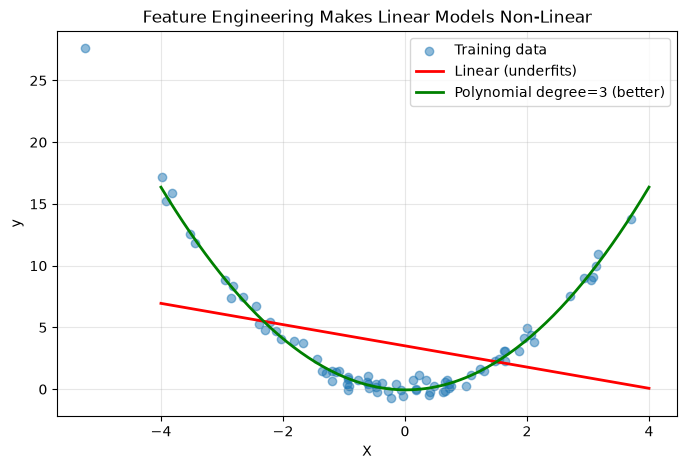

In [ ]:
# PART 6: FEATURE ENGINEERING
#
# WHAT IS FEATURE ENGINEERING?
#   Creating NEW input columns from old ones so a simple model can learn
#   a more complex pattern.
#
# POLYNOMIAL FEATURES (this cell):
#   If you only have x, a linear model can only fit a straight line:
#       y ≈ w*x + b
#
#   If you also give it x^2, x^3, ... it can fit curves, while STILL being
#   "linear" in the weights (linear in features, not in x):
#       y ≈ w0 + w1*x + w2*x^2 + w3*x^3
#
#   For 2 inputs and degree=2 you get things like:
#       [1, x1, x2, x1^2, x1*x2, x2^2]
#
# WHAT THE GRAPH SHOWS:
#   Dots     = data shaped like a U (y ≈ x^2 + noise)
#   Red line = plain linear model → underfits (can't bend)
#   Green    = same linear model but on polynomial features → follows the curve

# Polynomial Features Transform

class PolynomialFeatures:
    """
    Expand X into polynomial / interaction features.
    degree=2 with 2 cols → [1, x1, x2, x1^2, x1*x2, x2^2]
    """
    def __init__(self, degree=2, include_bias=True):
        self.degree = degree              # highest power to include (e.g. 3 → up to x^3)
        self.include_bias = include_bias  # if True, add a column of 1s (the intercept term)
    
    def fit_transform(self, X):
        # X shape: (n_samples, n_features)
        n_samples, n_features = X.shape
        features = []
        
        # Column of 1s → lets the model learn bias as a normal weight
        if self.include_bias:
            features.append(np.ones(n_samples))
        
        # For each degree d=1,2,...,degree:
        #   multiply features together according to each index tuple
        #   e.g. indices (0,0) → X[:,0] * X[:,0] = x^2
        #        indices (0,0,0) → x^3
        for d in range(1, self.degree + 1):
            for indices in self._combinations_with_replacement(n_features, d):
                feature = np.ones(n_samples)
                for idx in indices:
                    feature *= X[:, idx]
                features.append(feature)
        
        # Stack all new columns side by side → wider X
        return np.column_stack(features)
    
    def _combinations_with_replacement(self, n, r):
        """All ways to pick r feature indexes, repeats allowed (order doesn't matter).
        Example: n=1,r=2 → (0,0); n=2,r=2 → (0,0), (0,1), (1,1)
        """
        def helper(start, remaining):
            if remaining == 0:
                yield ()
                return
            for i in range(start, n):
                # pass i (not i+1) so the same feature can repeat: x*x = x^2
                for rest in helper(i, remaining - 1):
                    yield (i,) + rest
        yield from helper(0, r)


# --- Demo: curved data that a straight line can't fit well ---
np.random.seed(42)
X_nonlin = np.random.randn(100, 1) * 2                 # one input feature x
y_nonlin = X_nonlin.ravel()**2 + np.random.randn(100) * 0.5  # target ≈ x^2 + noise

# (leftover demo line — classification attempt; regression below is the real demo)
lr_linear = LogisticRegression(lr=0.1, n_epochs=100)
lr_linear.fit(
    np.column_stack([np.ones(80), X_nonlin[:80]]),
    (y_nonlin[:80] > 1).astype(int),
)

# Plain linear regression on raw x (expects a straight line → underfits the U-shape)
from sklearn.linear_model import LinearRegression as SKLR
sk_lr = SKLR()
sk_lr.fit(X_nonlin[:80], y_nonlin[:80])

# Same model, but inputs are [1, x, x^2, x^3] → can bend to fit the curve
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X_nonlin[:80])  # expand features
sk_lr_poly = SKLR()
sk_lr_poly.fit(X_poly, y_nonlin[:80])

# Predict on a smooth grid for plotting
X_test = np.linspace(-4, 4, 200).reshape(-1, 1)
y_pred_linear = sk_lr.predict(X_test)
y_pred_poly = sk_lr_poly.predict(poly.fit_transform(X_test))

plt.figure(figsize=(8, 5))
plt.scatter(X_nonlin[:80], y_nonlin[:80], alpha=0.5, label='Training data')
plt.plot(X_test, y_pred_linear, 'r-', linewidth=2, label='Linear (underfits)')
plt.plot(X_test, y_pred_poly, 'g-', linewidth=2, label='Polynomial degree=3 (better)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Feature Engineering Makes Linear Models Non-Linear')
plt.grid(True, alpha=0.3)
plt.show()
# Takeaway: you didn't make the model "nonlinear magic" —
# you gave it better ingredients (x^2, x^3) so a linear recipe could fit a curve.

# Key lesson: Feature engineering can make a linear model solve non-linear problems. 
# Neural networks learn their own feature transformations internally — that's why they're so powerful.

In [37]:
summary_day3 = """
DAY 3 KEY INSIGHTS:

1. LINEAR REGRESSION:
   - Closed-form: w = (X^T X)^(-1) X^T y (exact, but O(n³))
   - Gradient descent: iterative, scales to millions of features
   - L2 regularization shrinks weights → reduces overfitting

2. LOGISTIC REGRESSION:
   - Sigmoid converts any real number to [0,1] probability
   - Binary cross-entropy is the right loss for classification
   - Linear decision boundary: can't solve XOR without features

3. DECISION TREES:
   - Split on feature that reduces Gini impurity most
   - Non-linear, interpretable, but prone to overfitting
   - Random Forest: ensemble with bootstrapping + random features

4. EVALUATION:
   - Accuracy is misleading for imbalanced data
   - Precision/Recall/F1 give a fuller picture
   - ROC AUC measures ranking quality
   - K-fold CV gives reliable performance estimates

5. BIAS-VARIANCE:
   - High bias: model too simple (both train & test error high)
   - High variance: model too complex (train error=0, test error high)
   - Learning curves reveal which problem you have
   - More data helps with variance, not bias

6. FEATURE ENGINEERING:
   - Polynomial features give linear models non-linear power
   - Neural networks learn features automatically
   - The most impactful ML work is often in features, not models
"""
print(summary_day3)


DAY 3 KEY INSIGHTS:

1. LINEAR REGRESSION:
   - Closed-form: w = (X^T X)^(-1) X^T y (exact, but O(n³))
   - Gradient descent: iterative, scales to millions of features
   - L2 regularization shrinks weights → reduces overfitting

2. LOGISTIC REGRESSION:
   - Sigmoid converts any real number to [0,1] probability
   - Binary cross-entropy is the right loss for classification
   - Linear decision boundary: can't solve XOR without features

3. DECISION TREES:
   - Split on feature that reduces Gini impurity most
   - Non-linear, interpretable, but prone to overfitting
   - Random Forest: ensemble with bootstrapping + random features

4. EVALUATION:
   - Accuracy is misleading for imbalanced data
   - Precision/Recall/F1 give a fuller picture
   - ROC AUC measures ranking quality
   - K-fold CV gives reliable performance estimates

5. BIAS-VARIANCE:
   - High bias: model too simple (both train & test error high)
   - High variance: model too complex (train error=0, test error high)
   - Le

In [ ]:
# CHALLENGE: Build a complete ML pipeline
# 1. Load the breast cancer dataset (or any binary classification)
# 2. Implement StandardScaler (subtract mean, divide by std)
# 3. Apply it to the data
# 4. Train Logistic Regression, Decision Tree, Random Forest
# 5. Evaluate with 5-fold CV
# 6. Print a comparison table
#
# HOW THIS SOLUTION WORKS (big picture):
#   Raw medical measurements have different scales (e.g. area vs texture).
#   StandardScaler puts every feature on a similar scale (mean 0, std 1),
#   which helps Logistic Regression's gradient descent a lot.
#   Trees care less about scale, but we still scale inside CV the same way
#   for a fair comparison.
#   Then we grade each model with 5-fold CV (5 quizzes, average the score).

from sklearn.datasets import load_breast_cancer

# ---------------------------------------------------------------------------
# 1) Load data: 569 samples, 30 features, labels 0/1 (malignant(harmful)/benign(safe))
# ---------------------------------------------------------------------------
data = load_breast_cancer()
X_bc = data.data          # shape (569, 30)
y_bc = data.target        # shape (569,)  — binary classes
print(f"Dataset: {data.DESCR.split(chr(10))[0]}")
print(f"X shape: {X_bc.shape}, y shape: {y_bc.shape}")
print(f"Classes: {data.target_names} | counts: {np.bincount(y_bc)}")


# ---------------------------------------------------------------------------
# 2) StandardScaler from scratch
#    For each feature column:
#      scaled = (x - mean) / std
#    After scaling, typical values are around -2..+2 instead of huge raw ranges.
# ---------------------------------------------------------------------------
class StandardScaler:
    """Subtract train mean, divide by train std (per feature)."""

    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        # Learn scaling stats ONLY from training data
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        # Avoid divide-by-zero if a column is constant
        self.std_ = np.where(self.std_ == 0, 1.0, self.std_)
        return self

    def transform(self, X):
        # Apply the already-learned mean/std (used for train AND test)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# ---------------------------------------------------------------------------
# 3) Demo: apply scaler on full X (just to show before/after)
#    IMPORTANT: in CV below we fit the scaler on TRAIN folds only
#    so test data never leaks into the scaling numbers.
# ---------------------------------------------------------------------------
scaler_demo = StandardScaler()
X_bc_scaled_demo = scaler_demo.fit_transform(X_bc)
print("\nBefore scaling (feature 0): "
      f"mean={X_bc[:, 0].mean():.2f}, std={X_bc[:, 0].std():.2f}")
print("After scaling  (feature 0): "
      f"mean={X_bc_scaled_demo[:, 0].mean():.2f}, std={X_bc_scaled_demo[:, 0].std():.2f}")


# ---------------------------------------------------------------------------
# 5) 5-fold CV that scales inside each fold (no leakage)
# ---------------------------------------------------------------------------
def k_fold_cv_with_scaling(model_class, X, y, k=5, **model_kwargs):
    """
    Same idea as earlier k-fold, plus:
      - fit StandardScaler on the train fold
      - transform train + test with those stats
      - then fit/predict the model
    Returns mean accuracy and std across folds.
    """
    n_samples = len(y)
    fold_size = n_samples // k
    indices = np.random.permutation(n_samples)
    scores = []

    for fold in range(k):
        test_start = fold * fold_size
        test_end = (fold + 1) * fold_size if fold < k - 1 else n_samples
        test_idx = indices[test_start:test_end]
        train_idx = np.setdiff1d(indices, test_idx)

        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx], y[test_idx]

        # Scale using TRAIN stats only
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        scores.append(np.mean(y_pred == y_te))

    return np.mean(scores), np.std(scores)


# ---------------------------------------------------------------------------
# 4 + 5 + 6) Train/evaluate three models with CV, print comparison table
# ---------------------------------------------------------------------------
np.random.seed(42)

models_to_try = [
    # name, class, kwargs
    ("Logistic Regression", LogisticRegression, {"lr": 0.5, "n_epochs": 400}),
    ("Decision Tree (depth=4)", DecisionTree, {"max_depth": 4}),
    # fewer trees / features so from-scratch forest finishes in reasonable time
    ("Random Forest (5 trees)", RandomForest, {
        "n_trees": 5, "max_depth": 4, "max_features": 5
    }),
]

print("\n" + "=" * 56)
print("BREAST CANCER — 5-Fold CV Comparison")
print("=" * 56)
print(f"{'Model':<28} {'Mean Acc':>10} {'Std':>10}")
print("-" * 56)

results = []
for name, cls, kwargs in models_to_try:
    print(f"Evaluating {name}...")
    mean_acc, std_acc = k_fold_cv_with_scaling(cls, X_bc, y_bc, k=5, **kwargs)
    results.append((name, mean_acc, std_acc))
    print(f"{name:<28} {mean_acc:>10.3f} {std_acc:>10.3f}")

print("-" * 56)
best = max(results, key=lambda t: t[1])
print(f"Best mean accuracy: {best[0]} ({best[1]:.3f})")
print("""
How to read this:
  Mean Acc = average quiz score across 5 folds (higher better)
  Std      = how much scores bounced (lower = more stable)

Why scale?
  Logistic Regression uses gradients — huge raw features can dominate.
  Trees split on thresholds — scale matters less, but same CV recipe is fair.
""")


Dataset: .. _breast_cancer_dataset:
X shape: (569, 30), y shape: (569,)
Classes: ['malignant' 'benign'] | counts: [212 357]

Before scaling (feature 0): mean=14.13, std=3.52
After scaling  (feature 0): mean=-0.00, std=1.00

BREAST CANCER — 5-Fold CV Comparison
Model                          Mean Acc        Std
--------------------------------------------------------
Evaluating Logistic Regression...
Logistic Regression               0.981      0.014
Evaluating Decision Tree (depth=4)...
Decision Tree (depth=4)           0.930      0.012
Evaluating Random Forest (5 trees)...
  Trained tree 5/5
  Trained tree 5/5
  Trained tree 5/5
  Trained tree 5/5
  Trained tree 5/5
Random Forest (5 trees)           0.937      0.032
--------------------------------------------------------
Best mean accuracy: Logistic Regression (0.981)

How to read this:
  Mean Acc = average quiz score across 5 folds (higher better)
  Std      = how much scores bounced (lower = more stable)

Why scale?
  Logistic Regr